# Настройка инструментов

<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Инициализация среды</p></div>


*Импортируем библиотеки для работы с данными.*


In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno
# Обёртки для диаграмм
from researchers_tools import (
    custom_pie_chart,
    custom_hist_with_boxplot
)

*Загрузим конфигурации research обалсти.*

In [2]:
from settings import CONFIGS_DIR

import json

with open(CONFIGS_DIR / 'baseline_v1.json', encoding="utf-8") as f:
    config = json.load(f)

Инструменты пайплайна

In [3]:
from research.preprocessing.surface_processing import TitanicPreprocessor

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 242px;font-weight: 600;">Настройка визуализации</p></div>


*Настройка визуализации.*


In [4]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'

from core.researchers_tools.settings import (
    GRAPH_STYLES,
    PROP_CYCLE,
)

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=PROP_CYCLE)
plt.rcParams.update(GRAPH_STYLES)


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 319px;font-weight: 600;">Загрузка и настройка ресурсов</p></div>


**Наименование:** titanic.<br>**Путь к файлу:** datasets/raw/train.csv <br><br>


In [ ]:
from settings import RAW_DATASET_DIR

titanic = pd.read_csv(
    RAW_DATASET_DIR / config["raw_datasets"]["train"]['titanic']
)

**Новая структура данных:**

- **titanic**
- `passenger_id` — уникальный номер пассажира;
- `ticket_id` — номер билета;
- `name` — имя пассажира;
- `sex` — пол;
- `age` — Возраст в годах (возраст указывается дробным числом, если он меньше 1, если возраст указан приблизительно, то в виде xx.5);
- `same_importance_relatives` — Количество братьев и сестер / супругов на борту «Титаника»:
    * Sibling = брат, сестра, сводный брат, сводная сестра;
    * Spouse = муж, жена (любовницы и невесты остались без внимания).
- `high_importance_relatives` — родителей / детей на борту «Титаника»:
    * Parent = мать, отец;
    * Child = доч, сын, сводная дочь, сводный сын;
    * Некоторые дети путешествовали исключительно с няней, поэтому для них parch=0.
- `category_significance` — показатель социально-экономического статуса:
    * 1-е место = высший;
    * 2-е место = средний;
    * 3-е место = низший.
- `fare` — стоимость проезда для пассажиров;
- `cabin` — номер каюты;
- `survived` — выживание в катастрофе 0 = Нет, 1 = Да;
- `embarked` - место посадки (порт):
- C = Cherbourg;
- Q = Queenstown;
- S = Southampton.

<br> <br>


*Переименуем столбцы таблиц под описанную выше структуру.*


In [6]:
titanic.head(0)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [7]:
titanic = titanic.rename(columns={
    'PassengerId': 'passenger_id',
    'Ticket': 'ticket_id',
    'Name': 'name',
    'Sex': 'sex',
    'Age': 'age',
    'SibSp': 'same_importance_relatives',
    'Parch': 'high_importance_relatives',
    'Pclass': 'category_significance',
    'Fare': 'fare',
    'Cabin': 'cabin',
    'Survived': 'survived',
    'Embarked': 'embarked',
})

titanic = titanic[
    [
        'passenger_id',
        'ticket_id',
        'name',
        'sex',
        'age',
        'same_importance_relatives',
        'high_importance_relatives',
        'category_significance',
        'fare',
        'cabin',
        'survived',
        'embarked',
    ]
]

titanic.head(0)


,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


# Общая информация


**Название таблицы**


In [8]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   passenger_id               891 non-null    int64  
 1   ticket_id                  891 non-null    str    
 2   name                       891 non-null    str    
 3   sex                        891 non-null    str    
 4   age                        714 non-null    float64
 5   same_importance_relatives  891 non-null    int64  
 6   high_importance_relatives  891 non-null    int64  
 7   category_significance      891 non-null    int64  
 8   fare                       891 non-null    float64
 9   cabin                      204 non-null    str    
 10  survived                   891 non-null    int64  
 11  embarked                   889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


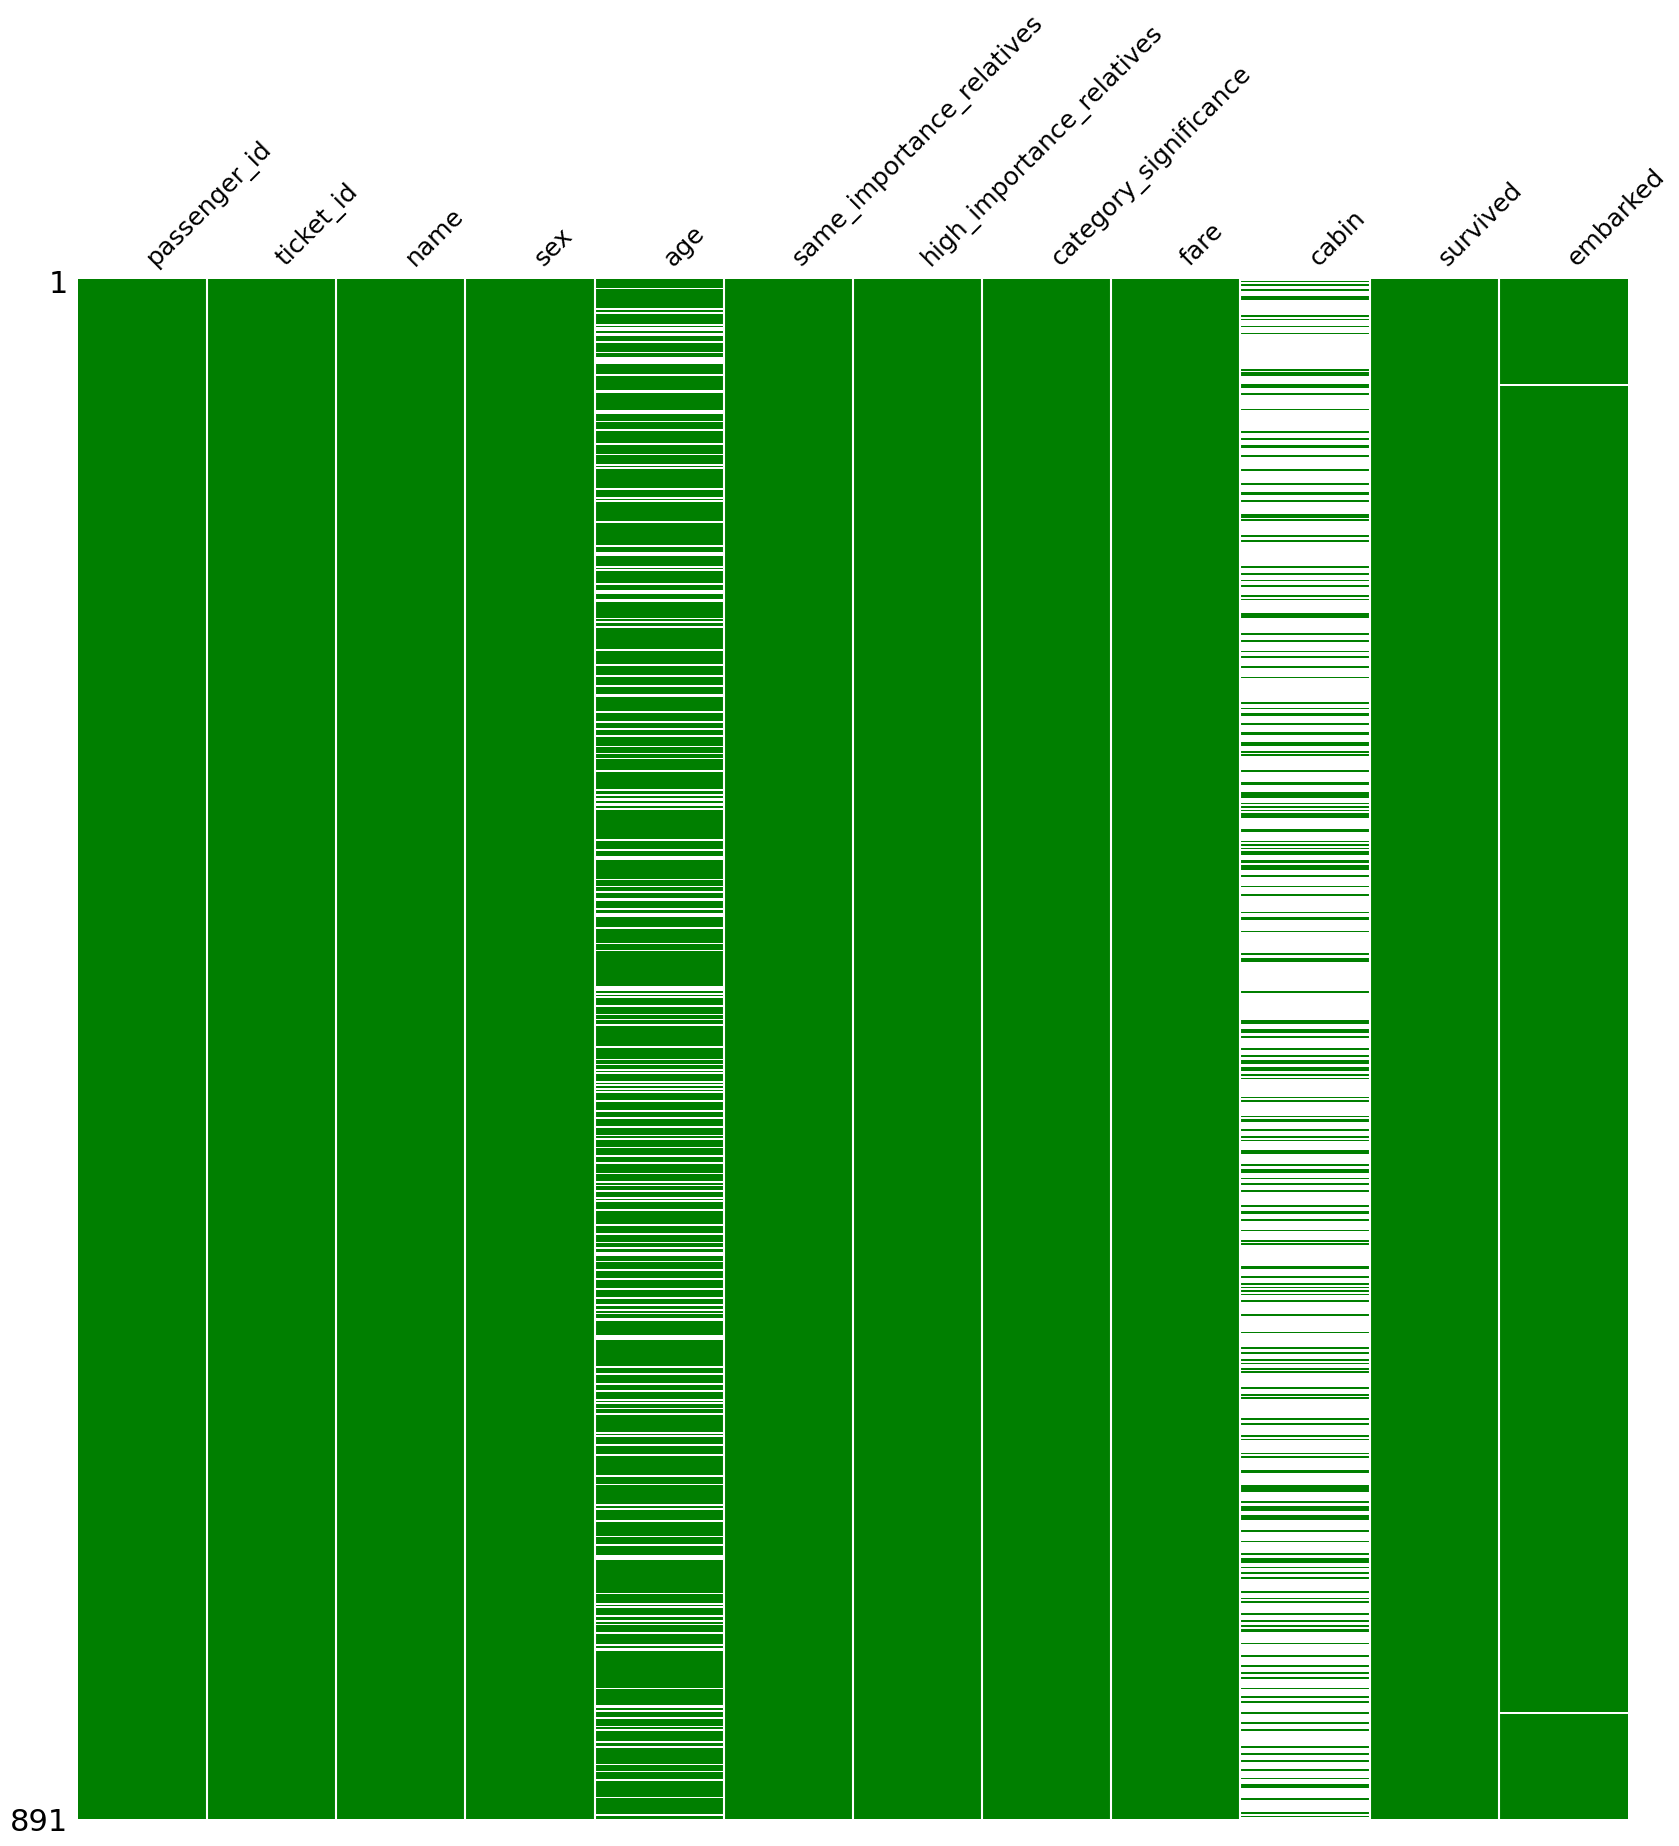

In [9]:
msno.matrix(
    titanic,
    color=(0, 0.5, 0),
    fontsize=18,
    sparkline=False,
    figsize=(20, 20)
);

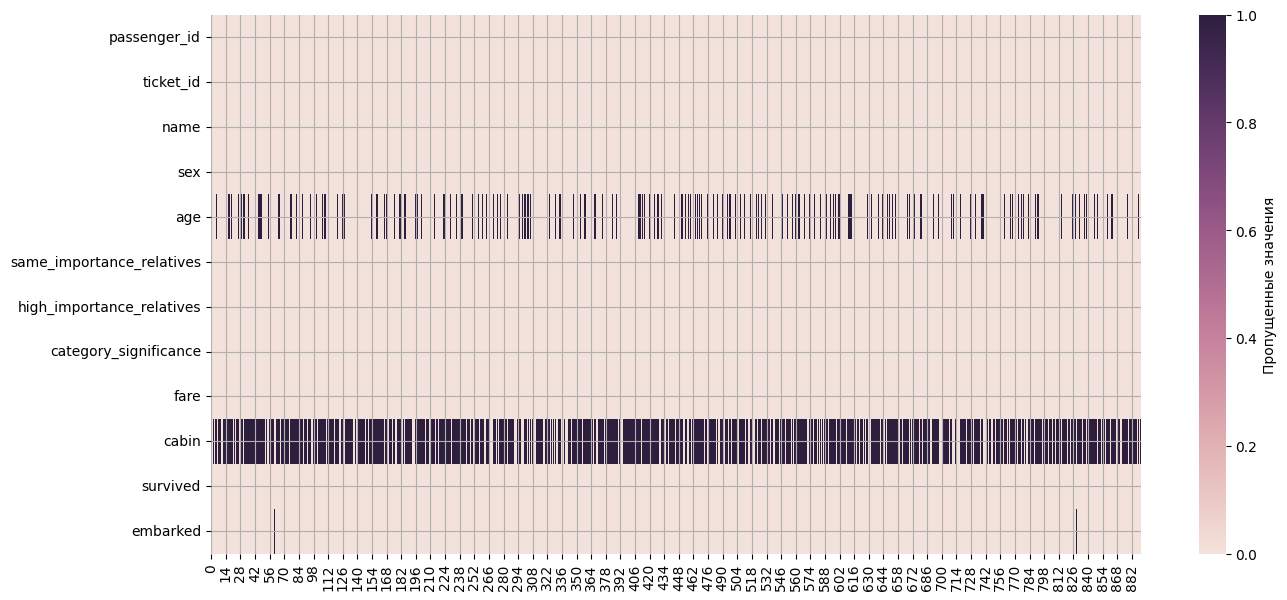

In [10]:
plt.figure(figsize=(15, 7))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(
    titanic.isna().transpose(),
    cmap=cmap,
    cbar_kws={'label': 'Пропущенные значения'}
);

*Посмотрим есть ли зависимость между пропусками.*


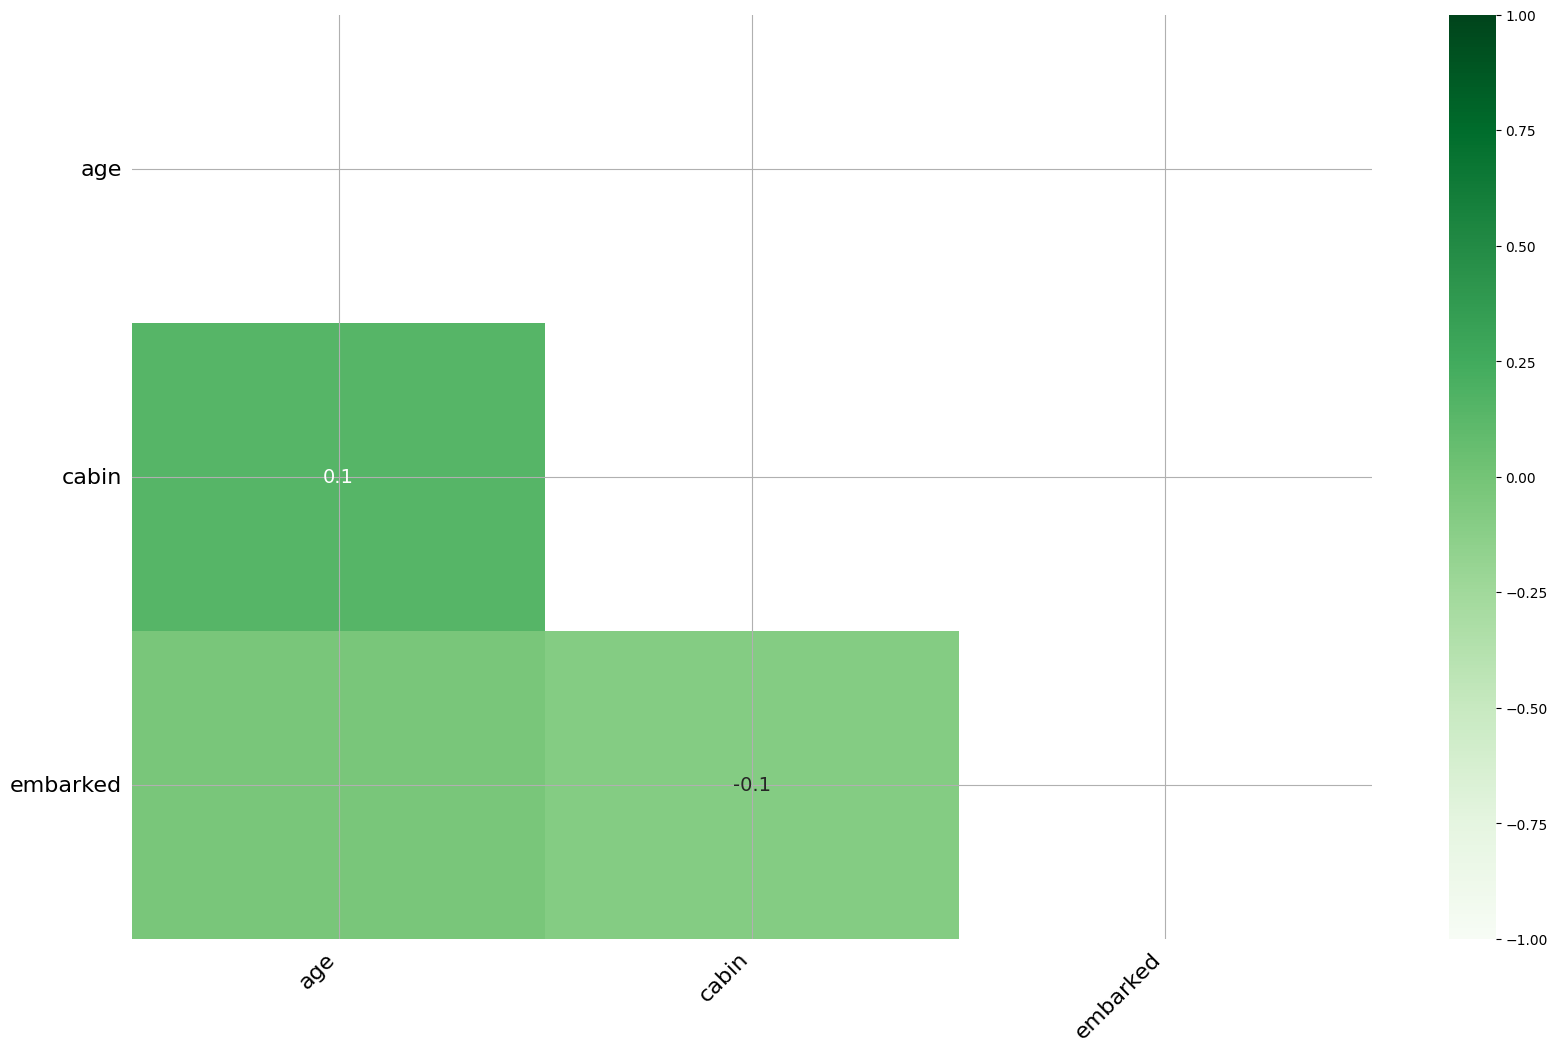

In [11]:
msno.heatmap(titanic, cmap='Greens');

# Предобработка данных


## DF @titanic `passenger_id`.


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 121px;font-weight: 600;">Общий вывод</p></div>


---
**Аномалии:**
- Не обнаружены
---

**Дубликаты:**
- Отсутствуют
---


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 77px;font-weight: 600;">Метрики</p></div>


In [12]:
print(
    'Статистика:',
    titanic['passenger_id'].describe(include="all"),
)
print()

duplicates = (
    titanic[titanic['passenger_id'].duplicated()]['passenger_id'].value_counts()
)

print(
    'Максимальное число записей на одного пассажира =',
    duplicates.max(),
)
print()

non_repeated = titanic['passenger_id'].value_counts()
non_repeated = non_repeated[non_repeated == 1].index

print(
    "id, которые не повторялись в DataFrame:",
    len(list(non_repeated))
)

Статистика: count    891.000000
mean     446.000000
std      257.353842
min        1.000000
25%      223.500000
50%      446.000000
75%      668.500000
max      891.000000
Name: passenger_id, dtype: float64

Максимальное число записей на одного пассажира = nan

id, которые не повторялись в DataFrame: 891


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


## DF @titanic `ticket_id`.


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 121px;font-weight: 600;">Общий вывод</p></div>


---
**Аномалии:**
- a. Симолы "." и "/".

**Причины:**
- a. Не обнаружены.

**Методы устранения:**
- a. Не устраняем, так как нет дубликатов с теми, в которых символов нет.
---

**Дубликаты:**
- Присутствуют из-за того, что семьи имели возможность получить билеты с одним номером или один билет.
---


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 77px;font-weight: 600;">Метрики</p></div>


In [13]:
print(
    'Статистика:',
    titanic['ticket_id'].describe(include="all"),
)
print()

duplicates = (
    titanic[titanic['ticket_id'].duplicated()]['ticket_id'].value_counts()
)

print(
    'Максимальное число записей на билет одного пассажира =',
    duplicates.max(),
)
print()

non_repeated = titanic['ticket_id'].value_counts()
non_repeated = non_repeated[non_repeated == 1].index

print(
    "id, которые не повторялись в DataFrame:",
    len(list(non_repeated))
)

Статистика: count        891
unique       681
top       347082
freq           7
Name: ticket_id, dtype: object

Максимальное число записей на билет одного пассажира = 6

id, которые не повторялись в DataFrame: 547


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Устранение аномалий</p></div>


*Было замечено, что многие номера билетов имеют символы "/" и ".", которые отличают их от таких же, только без этих элементов, но самое важное здесь то, что при удалении этих символов ни один идентификатор билета не совпадёт на 100%: будут отличаеться одним символом, двумя и так далее.*

*Из вышесказанного следует вывод - редактировать признак не имеет смысл, потому что глобально это ничего не изменит. У нас уже есть все признаки, которые говорят о качестве билета и в них нет не единого пропуска. Если результат и будет, то будет минимальный. `ticket_id` в наших данных является категориальным признакомом и несёт большую часть смысла в этом ключе - по нему можно сгруппировать семьи.*

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 231px;font-weight: 600;">Устранение дубликатов</p></div>


In [14]:
titanic[titanic['ticket_id'] == "349909"]

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked
7,8,349909,"Palsson, Master. Gosta Leonard",male,2.0,3,1,3,21.075,NaN,0,S
24,25,349909,"Palsson, Miss. Torborg Danira",female,8.0,3,1,3,21.075,NaN,0,S
374,375,349909,"Palsson, Miss. Stina Viola",female,3.0,3,1,3,21.075,NaN,0,S
567,568,349909,"Palsson, Mrs. Nils (Alma Cornelia Berglund)",female,29.0,0,4,3,21.075,NaN,0,S


**Вывод**

*Было замечено, что при желании семьям выдавали один id билета на всех. Это повторяется многократно. В примере выше семья Palsson*

In [15]:
print(
    '15 летний юноша, который ехал без родителей. Вероятно имеет 17ти летнюю сестру. Оба имеют отдельные билеты',
)

titanic[titanic["ticket_id"].isin(["2695", "2690"])]

15 летний юноша, который ехал без родителей. Вероятно имеет 17ти летнюю сестру. Оба имеют отдельные билеты


,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked
352,353,2695,"Elias, Mr. Tannous",male,15.0,1,1,3,7.2292,NaN,0,C
532,533,2690,"Elias, Mr. Joseph Jr",male,17.0,1,1,3,7.2292,NaN,0,C


In [16]:
(
    titanic[titanic["ticket_id"]
    .isin(["2690", "2691", "2692", "2693", "2694", "2695"])]
    .sort_values("ticket_id")
)

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked
532,533,2690,"Elias, Mr. Joseph Jr",male,17.0,1,1,3,7.2292,NaN,0,C
362,363,2691,"Barbara, Mrs. (Catherine David)",female,45.0,0,1,3,14.4542,NaN,0,C
702,703,2691,"Barbara, Miss. Saiide",female,18.0,0,1,3,14.4542,NaN,0,C
296,297,2693,"Hanna, Mr. Mansour",male,23.5,0,0,3,7.2292,NaN,0,C
244,245,2694,"Attalah, Mr. Sleiman",male,30.0,0,0,3,7.2250,NaN,0,C
352,353,2695,"Elias, Mr. Tannous",male,15.0,1,1,3,7.2292,NaN,0,C


**Вывод:**

*То есть видим, сели в одном порту, стоимость билета одинаковая, фамилия одинаковая. Родителя я не нашёл. Едут отдельно. Детям 15 и 17 лет. То есть, выходит можно было в этом возрасте взять и отдельный билет, просто, люди брали семьями.*

In [17]:
titanic[titanic["name"].str.contains('Andersson')]

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked
13,14,347082,"Andersson, Mr. Anders Johan",male,39.0,1,5,3,31.2750,NaN,0,S
68,69,3101281,"Andersson, Miss. Erna Alexandra",female,17.0,4,2,3,7.9250,NaN,1,S
119,120,347082,"Andersson, Miss. Ellis Anna Maria",female,2.0,4,2,3,31.2750,NaN,0,S
146,147,350043,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,3,7.7958,NaN,1,S
541,542,347082,"Andersson, Miss. Ingeborg Constanzia",female,9.0,4,2,3,31.2750,NaN,0,S
542,543,347082,"Andersson, Miss. Sigrid Elisabeth",female,11.0,4,2,3,31.2750,NaN,0,S
610,611,347082,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",female,39.0,1,5,3,31.2750,NaN,0,S
813,814,347082,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,3,31.2750,NaN,0,S
850,851,347082,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,3,31.2750,NaN,0,S


**Вывод:**

*Тоже странное семейство. Все едут под одним билетом, одна девочка 17ти лет 3101281 номер билета. Написано имеет 4 брата сестры. Видимо сводная. Вероятно просто в разное время брали билеты.*

*В общем, есть множество исключений из-за которых люди могли брать разные билеты. Факт остаётся фактом - есть дети, которые брали билет отдельно от родителей, братьев и сестёр.*

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


## DF @titanic `name`.


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 121px;font-weight: 600;">Общий вывод</p></div>


---
**Аномалии:**
- a. Обозначение осознанности, которое несёт смысл вставлено в имя (Master, Mr, Miss, Mrs), когда лучше его вынести в отдельный признак на равне с признаком `age`.

**Причины:**
- a. Не обнаружены.

**Методы устранения:**
- a. Создать признак `age_level`
---

**Дубликаты:**
- Не обнаружены;

**Причины:**
- a. В поле name заложены имена и фамилии. Из-за имени дубликатов практически нет, что ломает нам всю картину;

**Методы устранения:**
- a. Создать признак `family`;
---


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


## DF @titanic `sex`.


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 121px;font-weight: 600;">Общий вывод</p></div>


---
**Аномалии:**
- a. По какой-то причине на титанике было 577 человек мужского пола, в то время как женского пола всего 313.

**Причины:**
- a. Не обнаружены.

**Методы устранения:**
- a. Не устранены.
---

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Визуализация данных</p></div>


**Гистограмма и "ящик с усами" 1**


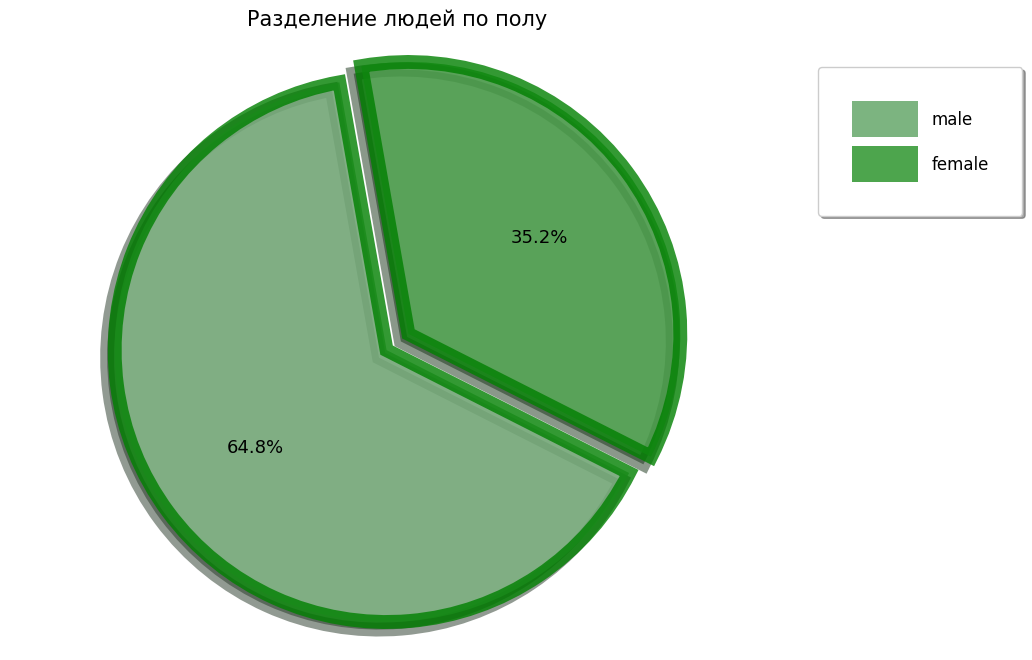

In [18]:
group_name = titanic['sex'].value_counts()

colors = ['#7cb480', '#4da54d']

custom_pie_chart(
    data=group_name,
    colors=colors,
    startangle=100,
    explode=[0.1, 0],
    title='Разделение людей по полу',
)


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 77px;font-weight: 600;">Метрики</p></div>


In [19]:
titanic["sex"].describe(include="all")

count      891
unique       2
top       male
freq       577
Name: sex, dtype: object

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>



## DF @titanic `age`.


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 121px;font-weight: 600;">Общий вывод</p></div>


---
**Аномалии:**
- a. Большое количество детей меньше года;
- b. 77% пропущенных значений - люди из 3ей категории;
- c. 5 человек старше 70.

**Причины:**
- a. Не установлены;
- b. Не установлены;
- c. Не установлены;

**Методы устранения:**
- a. Не устранены;
- b. Не устранены;
- c. Не устранены;
---

**Дубликаты:**
- Отсутствуют
---


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Визуализация данных</p></div>


**Гистограмма и "ящик с усами" 1**


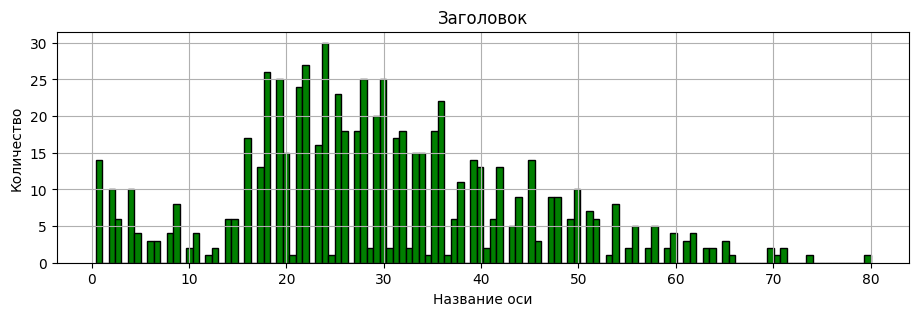

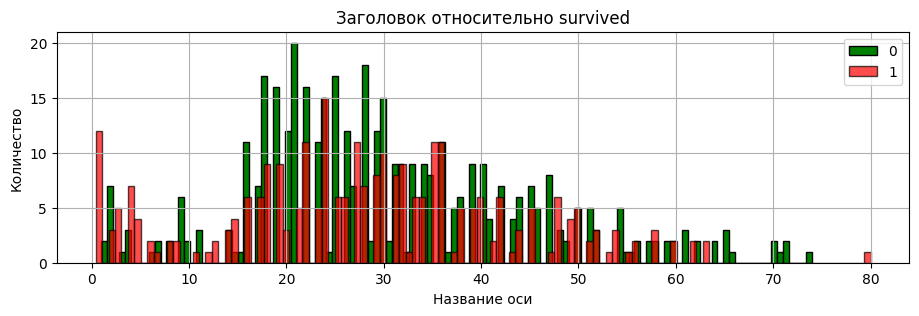

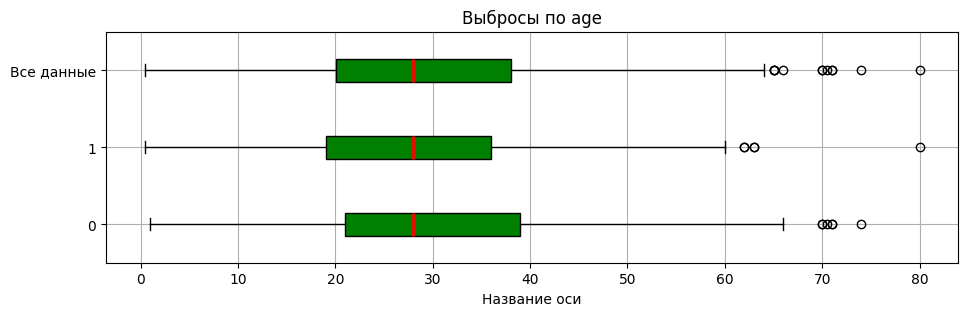

In [20]:
custom_hist_with_boxplot(
    dataframe=titanic,
    x_value_name='age',
    bins=120,
    target_name='survived',
    hist_title='Заголовок',
    x_label='Название оси',
    mode='overlay',
)


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 77px;font-weight: 600;">Метрики</p></div>


In [21]:
titanic["age"].describe(include="all")

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

In [22]:
print(
    'Данные начинаются с -',
    titanic['age'].min()
)
print(
    'Данные заканчиваюся -',
    titanic['age'].max(),
)

Данные начинаются с - 0.42
Данные заканчиваюся - 80.0


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 220px;font-weight: 600;">Устранение пропусков</p></div>


<font color="green">**Вывод по гистограмме и "ящику с усами" 1 из раздела "Визуализация":**</font>


In [23]:
titanic[titanic['age'].isna()]['category_significance'].value_counts()

category_significance
3    136
1     30
2     11
Name: count, dtype: int64

*Здесь и сейчас сложно проанализировать данный параметр,постараемся изучить его более детально в разделе EDA.*


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Устранение аномалий</p></div>


*Здесь и сейчас сложно проанализировать данный параметр,постараемся изучить его более детально в разделе EDA.*


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


## DF @titanic `same_importance_relatives`.


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 121px;font-weight: 600;">Общий вывод</p></div>


---
**Аномалии:**
- a. Не обнаружены;
---


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Визуализация данных</p></div>


**Гистограмма и "ящик с усами" 1**


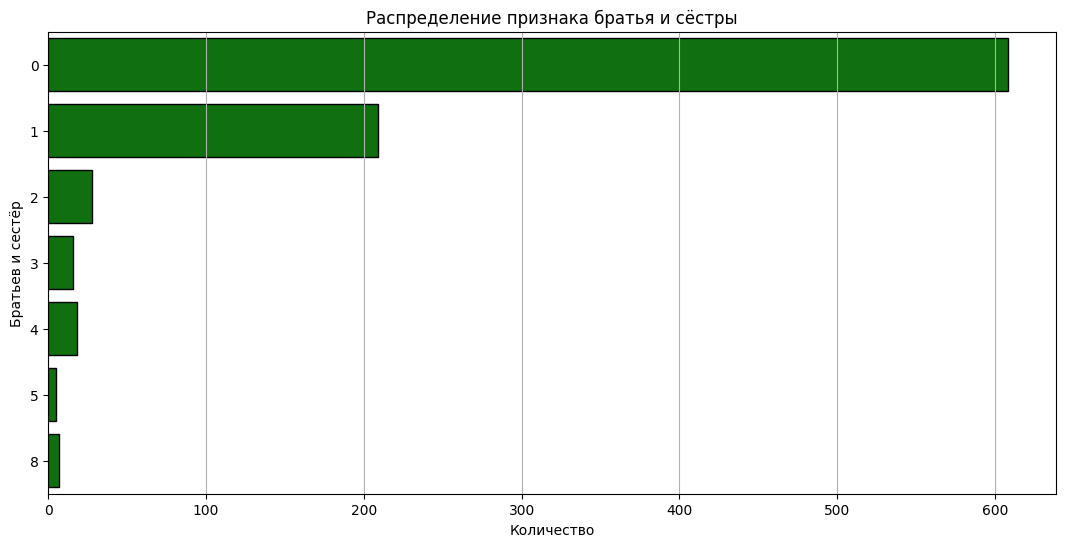

In [24]:
plt.figure(figsize=(13, 6))

sns.countplot(
    y='same_importance_relatives',
    data=titanic,
    legend=False
)

plt.title('Распределение признака братья и сёстры')
plt.ylabel('Братьев и сестёр')
plt.xlabel('Количество')

plt.show()


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 77px;font-weight: 600;">Метрики</p></div>


In [25]:
titanic["same_importance_relatives"].describe(include="all")

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: same_importance_relatives, dtype: float64

In [26]:
print(
    'Оценка сезонности:',
    (titanic['same_importance_relatives'].value_counts())[:5],
    '',
    sep='\n'
)

Оценка сезонности:
same_importance_relatives
0    608
1    209
2     28
4     18
3     16
Name: count, dtype: int64



<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Устранение аномалий</p></div>


<font color="green">**Вывод по гистограмме и "ящику с усами" 1 из раздела "Визуализация":**</font>


In [27]:
titanic[titanic['same_importance_relatives'] > 4].sort_values('ticket_id')

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked
59,60,CA 2144,"Goodwin, Master. William Frederick",male,11.0,5,2,3,46.90,NaN,0,S
71,72,CA 2144,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,3,46.90,NaN,0,S
386,387,CA 2144,"Goodwin, Master. Sidney Leonard",male,1.0,5,2,3,46.90,NaN,0,S
480,481,CA 2144,"Goodwin, Master. Harold Victor",male,9.0,5,2,3,46.90,NaN,0,S
683,684,CA 2144,"Goodwin, Mr. Charles Edward",male,14.0,5,2,3,46.90,NaN,0,S
159,160,CA. 2343,"Sage, Master. Thomas Henry",male,NaN,8,2,3,69.55,NaN,0,S
180,181,CA. 2343,"Sage, Miss. Constance Gladys",female,NaN,8,2,3,69.55,NaN,0,S
201,202,CA. 2343,"Sage, Mr. Frederick",male,NaN,8,2,3,69.55,NaN,0,S
324,325,CA. 2343,"Sage, Mr. George John Jr",male,NaN,8,2,3,69.55,NaN,0,S
792,793,CA. 2343,"Sage, Miss. Stella Anna",female,NaN,8,2,3,69.55,NaN,0,S


In [28]:
titanic[titanic['ticket_id'] == "CA 2144"]

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked
59,60,CA 2144,"Goodwin, Master. William Frederick",male,11.0,5,2,3,46.9,NaN,0,S
71,72,CA 2144,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,3,46.9,NaN,0,S
386,387,CA 2144,"Goodwin, Master. Sidney Leonard",male,1.0,5,2,3,46.9,NaN,0,S
480,481,CA 2144,"Goodwin, Master. Harold Victor",male,9.0,5,2,3,46.9,NaN,0,S
678,679,CA 2144,"Goodwin, Mrs. Frederick (Augusta Tyler)",female,43.0,1,6,3,46.9,NaN,0,S
683,684,CA 2144,"Goodwin, Mr. Charles Edward",male,14.0,5,2,3,46.9,NaN,0,S


In [29]:
titanic[titanic['ticket_id'] == "CA. 2343"]

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked
159,160,CA. 2343,"Sage, Master. Thomas Henry",male,NaN,8,2,3,69.55,NaN,0,S
180,181,CA. 2343,"Sage, Miss. Constance Gladys",female,NaN,8,2,3,69.55,NaN,0,S
201,202,CA. 2343,"Sage, Mr. Frederick",male,NaN,8,2,3,69.55,NaN,0,S
324,325,CA. 2343,"Sage, Mr. George John Jr",male,NaN,8,2,3,69.55,NaN,0,S
792,793,CA. 2343,"Sage, Miss. Stella Anna",female,NaN,8,2,3,69.55,NaN,0,S
846,847,CA. 2343,"Sage, Mr. Douglas Bullen",male,NaN,8,2,3,69.55,NaN,0,S
863,864,CA. 2343,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,3,69.55,NaN,0,S


*В конечном итоге выглядит не как однозначно аномалия, а как очень хорошая вспомогательная история для нашей модели, потому что сами данные логичны. Единсвенное, никак не могу найти их родителя. Пробовал искать по фамилии - результата нет. Есть вероятность, что родитель просто попал в тестовую выборку, следовательно качество нашей модели будет зависеть напрямую от правдивости данных. Если есть какие-то малейшие ошибки в информации, то она уже будет выдавать плохое качество.*


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


## DF @titanic `high_importance_relatives`.


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 121px;font-weight: 600;">Общий вывод</p></div>


---
**Аномалии:**
- a. `W./C. 6608` — единственная выявленная группа с неоднозначной структурой родственных связей. Возрастной и гендерный состав группы не позволяет однозначно интерпретировать отношения между пассажирами. Использование данной группы при построении семейных признаков может приводить к формированию недостоверных агрегатов.

**Причины:**
- a. Не установлена.

**Методы устранения:**
- a. Группа по билету W./C. 6608 исключена из дальнейшего анализа;
---


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Визуализация данных</p></div>


**Гистограмма и "ящик с усами" 1**


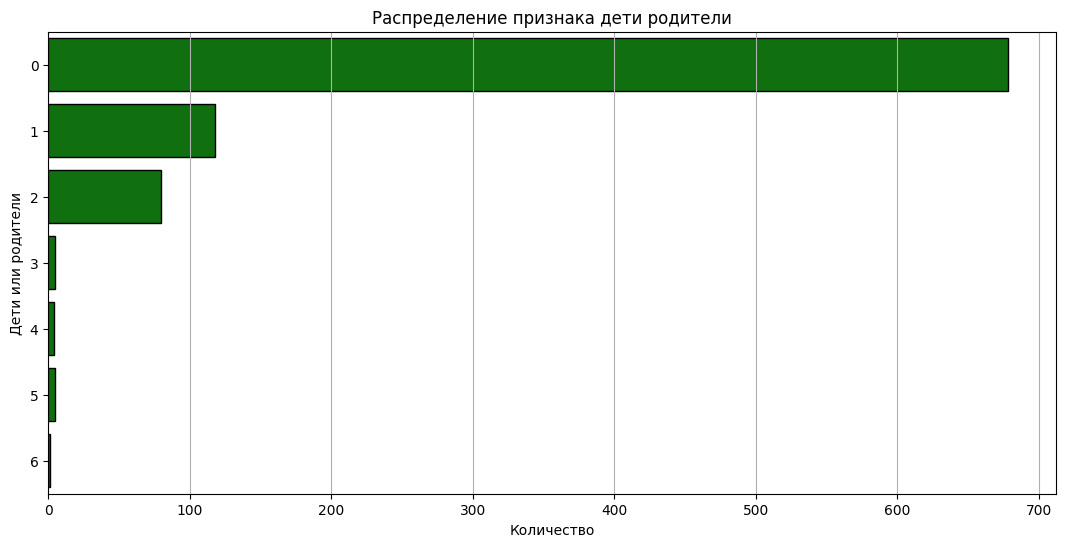

In [30]:
plt.figure(figsize=(13, 6))

sns.countplot(
    y='high_importance_relatives',
    data=titanic,
    legend=False,
)

plt.title('Распределение признака дети родители')
plt.ylabel('Дети или родители')
plt.xlabel('Количество')

plt.show()


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 77px;font-weight: 600;">Метрики</p></div>


In [31]:
titanic["high_importance_relatives"].describe(include="all")

count    891.000000
mean       0.381594
std        0.806057
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: high_importance_relatives, dtype: float64

In [32]:
print(
    'Оценка сезонности:',
    (titanic['high_importance_relatives'].value_counts())[:5],
    '',
    sep='\n'
)

Оценка сезонности:
high_importance_relatives
0    678
1    118
2     80
5      5
3      5
Name: count, dtype: int64



<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Устранение аномалий</p></div>


<font color="green">**Вывод по гистограмме и "ящику с усами" 1 из раздела "Визуализация":**</font>


In [33]:
titanic[titanic['high_importance_relatives'] > 2]

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked
13,14,347082,"Andersson, Mr. Anders Johan",male,39.0,1,5,3,31.2750,NaN,0,S
25,26,347077,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,3,31.3875,NaN,1,S
86,87,W./C. 6608,"Ford, Mr. William Neal",male,16.0,1,3,3,34.3750,NaN,0,S
167,168,347088,"Skoog, Mrs. William (Anna Bernhardina Karlsson)",female,45.0,1,4,3,27.9000,NaN,0,S
360,361,347088,"Skoog, Mr. Wilhelm",male,40.0,1,4,3,27.9000,NaN,0,S
437,438,29106,"Richards, Mrs. Sidney (Emily Hocking)",female,24.0,2,3,2,18.7500,NaN,1,S
438,439,19950,"Fortune, Mr. Mark",male,64.0,1,4,1,263.0000,C23 C25 C27,0,S
567,568,349909,"Palsson, Mrs. Nils (Alma Cornelia Berglund)",female,29.0,0,4,3,21.0750,NaN,0,S
610,611,347082,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",female,39.0,1,5,3,31.2750,NaN,0,S
638,639,3101295,"Panula, Mrs. Juha (Maria Emilia Ojala)",female,41.0,0,5,3,39.6875,NaN,0,S


**Вывод:**

В таком возрасте можно спокойно быть многодетными родителями, из-за чего признак будет иметь большое значение. Было замечено несколько странных результато - пассажирка 82 в 16 лет имеет 3 глубокие связи.*

*Отдельно из-за недоверия посмотрел пассажирку 438, которая достаточно молода и 859. Обе совершенно нормальные молодые мамы. Никаких аномалий не заметил.*

In [34]:
titanic[titanic['ticket_id'] == "W./C. 6608"]

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked
86,87,W./C. 6608,"Ford, Mr. William Neal",male,16.0,1,3,3,34.375,NaN,0,S
147,148,W./C. 6608,"Ford, Miss. Robina Maggie ""Ruby""",female,9.0,2,2,3,34.375,NaN,0,S
436,437,W./C. 6608,"Ford, Miss. Doolina Margaret ""Daisy""",female,21.0,2,2,3,34.375,NaN,0,S
736,737,W./C. 6608,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,3,34.375,NaN,0,S


**Вывод:**

*Мне абсолютно не понятно что здесь происходит. Будто 16 летний мальчик женат на 48 летней женщине. В целом, такая вероятность есть. Но в таком случаае это больше похоже на аномалию. Попробуем посмотреть сколько таких случаев в целом.*

*Просто, тут заметно, что даже в случае, когда данные попали в тестовую выборку, картина не изменится. Почему-то не стоит `same_importance_relatives` у 16ти летнего парня, поэтому мы не можем утверждать, что остальные ему сёстры.*

In [35]:
titanic[
    (titanic['age'] < 18) & (titanic['high_importance_relatives'] >= 3)
    ]

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked
86,87,W./C. 6608,"Ford, Mr. William Neal",male,16.0,1,3,3,34.375,NaN,0,S


**Вывод:**

*Единичный случай, поэтому я полагаю такую семью лучше удалить полностью.*

In [36]:
titanic = TitanicPreprocessor.remove_invalid_ticket_group(titanic)

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


## DF @titanic `category_significance`.


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 121px;font-weight: 600;">Общий вывод</p></div>


---
**Аномалии:**
- Не обнаружены

---


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Визуализация данных</p></div>


**Гистограмма и "ящик с усами" 1**


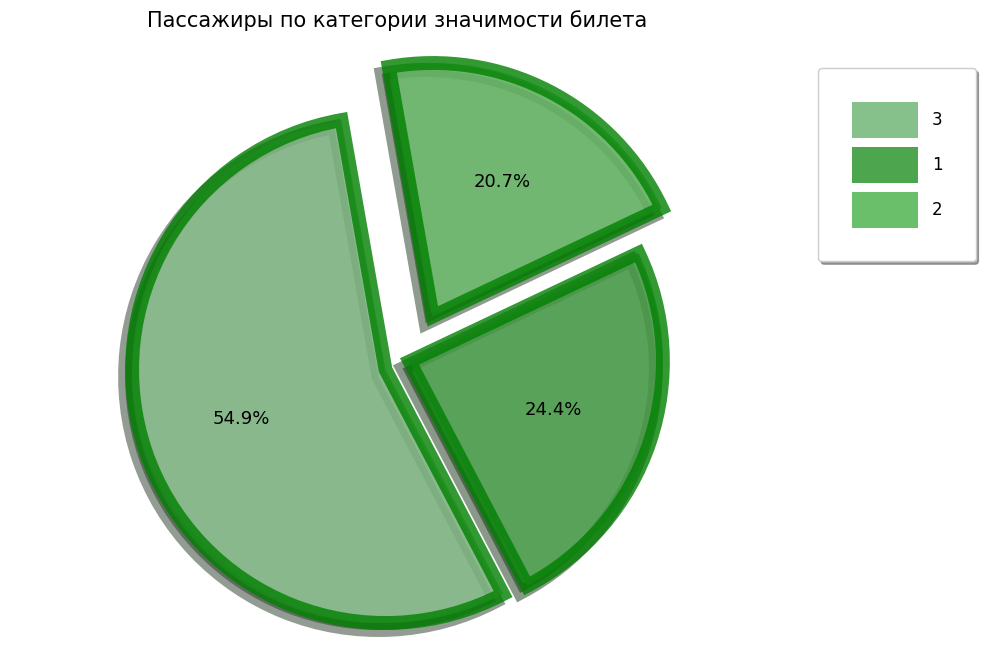

In [37]:
group_name = titanic['category_significance'].value_counts()

colors = ['#86c08a', '#4da54d', '#6abf6a']

custom_pie_chart(
    data=group_name,
    colors=colors,
    startangle=100,
    explode=[0.1, 0, 0.2],
    title='Пассажиры по категории значимости билета',
)


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


## DF @titanic `fare`.


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 121px;font-weight: 600;">Общий вывод</p></div>


---
**Аномалии:**
- Люди, которые заплатили сверх цену;

**Причины:**
- В большинстве своём эти люди брали несколько кабин на один билет;
- Вероятно на что-то влияют приписки внутри ticket_id;

**Методы устранения:**
- Можно попробовать разделить признак ticket_id на id и строчную преписку из букв;
- Нужно разделить людей, которые взяли одну кабину и людей, которые взяли несколько кабин, возможно, создать признак кол-во купленных кабин и отдельно букву кабины;
---

**Дубликаты:**
- Присутствуют

**Причины:**
- a. Нет ответа.
---

**Пропуски:**
- Есть пассажиры, которые заплатили 0.

**Методы устранения:**
- a. Заполнить самым часто встречающимся значением после того как выясним от каких признаков зависит цена билета;
---


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Визуализация данных</p></div>


**Гистограмма и "ящик с усами" 1, 2:**


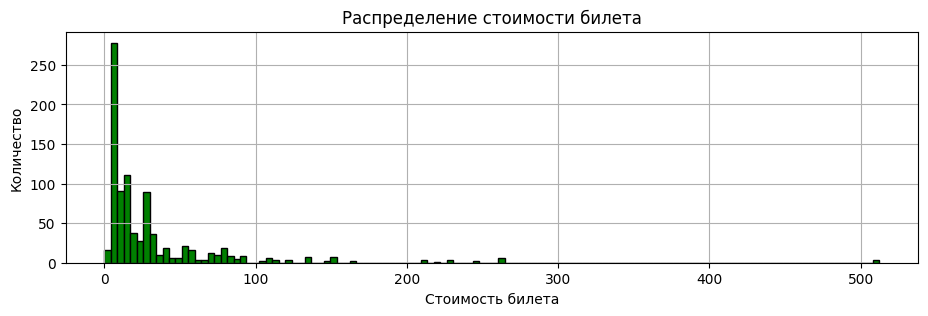

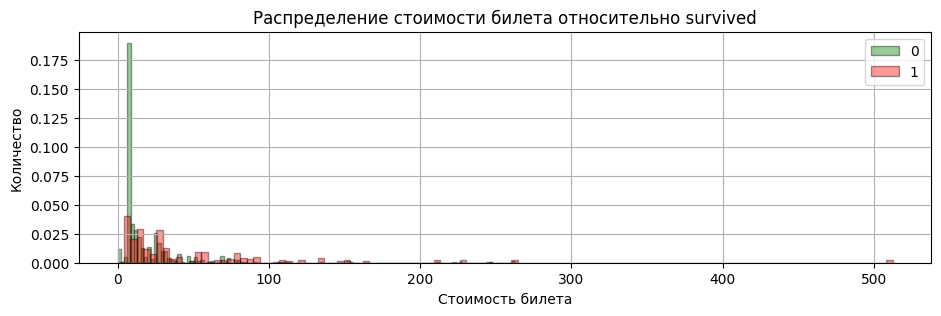

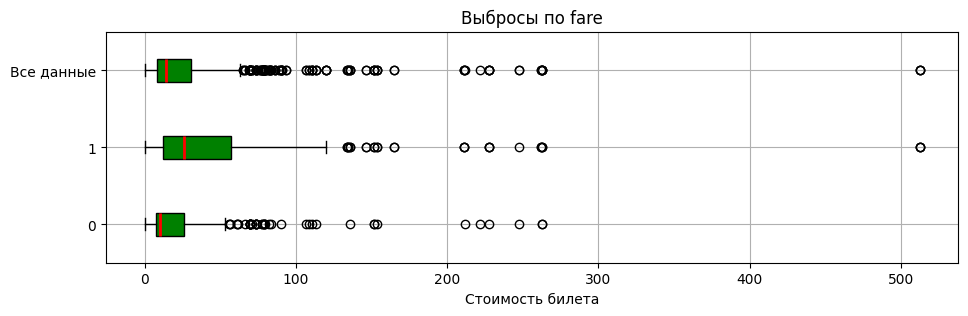

In [38]:
custom_hist_with_boxplot(
    dataframe=titanic,
    x_value_name='fare',
    bins=120,
    target_name='survived',
    hist_title='Распределение стоимости билета',
    x_label='Стоимость билета',
)


**Гистограмма и "ящик с усами" 3, 4:**

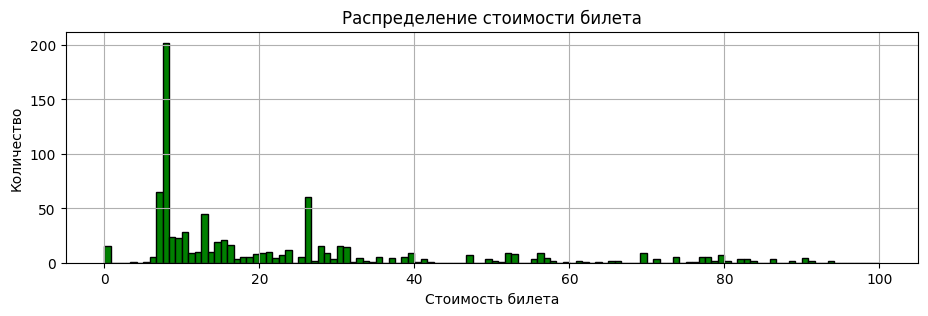

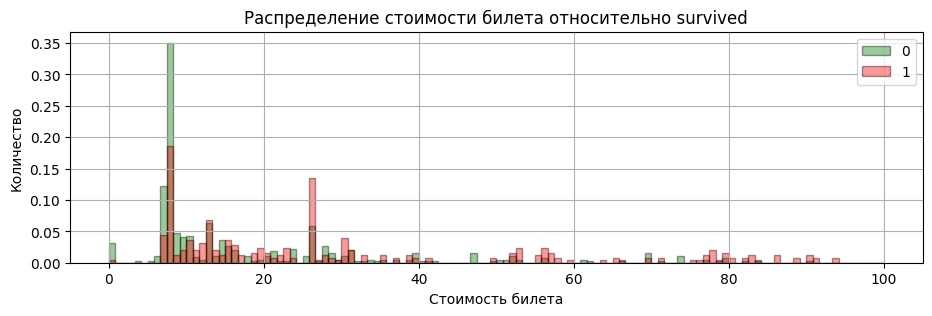

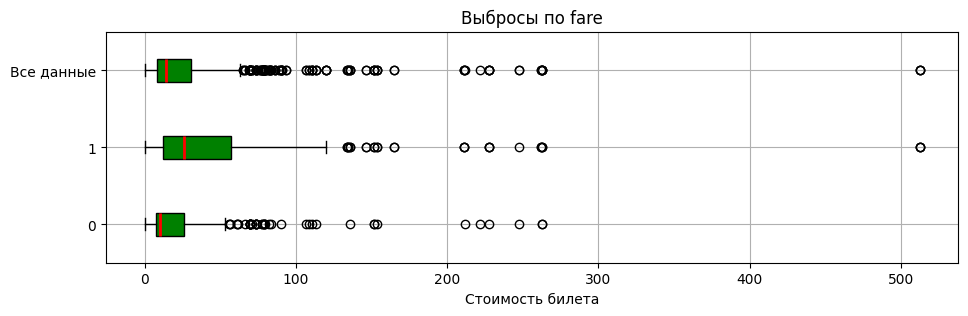

In [39]:
custom_hist_with_boxplot(
    dataframe=titanic,
    x_value_name='fare',
    bins=120,
    target_name='survived',
    hist_title='Распределение стоимости билета',
    x_label='Стоимость билета',
    range=(0, 100)
)


**Гистограмма и "ящик с усами" 5:**


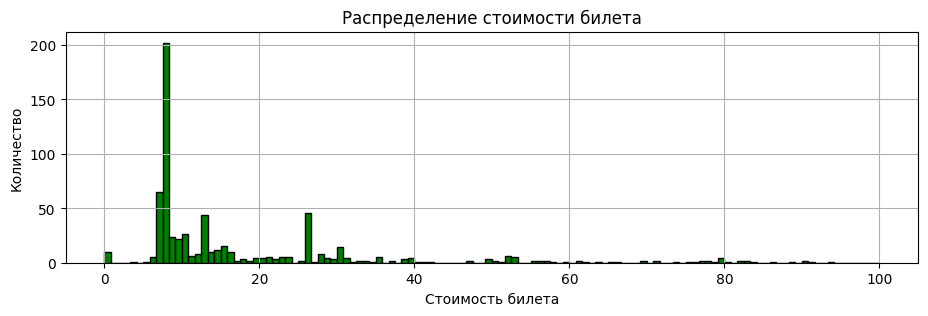

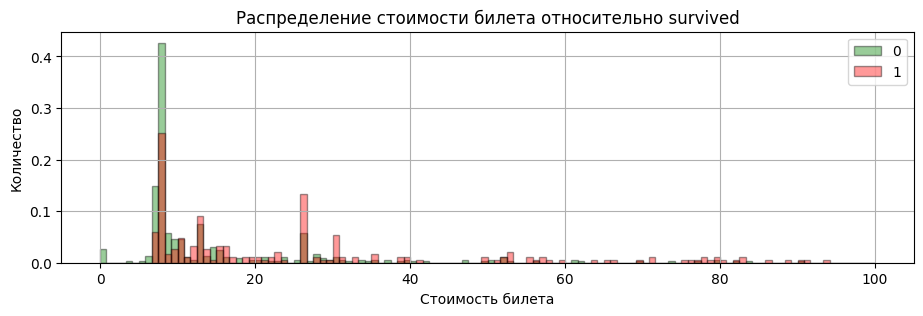

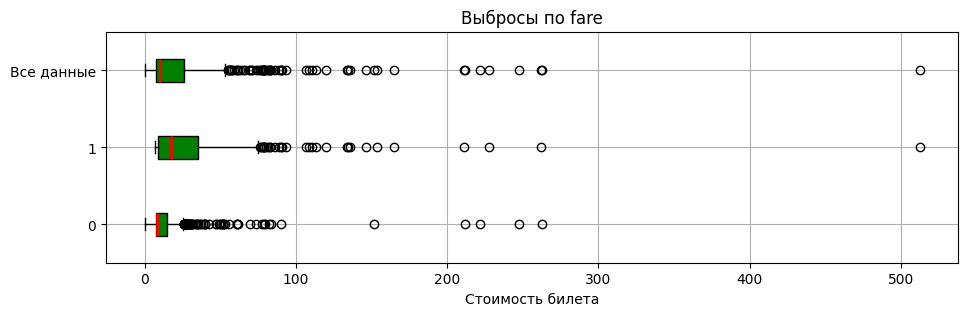

In [40]:
custom_hist_with_boxplot(
    dataframe=titanic.drop_duplicates(subset='ticket_id', keep='first'),
    x_value_name='fare',
    bins=120,
    target_name='survived',
    hist_title='Распределение стоимости билета',
    x_label='Стоимость билета',
    range=(0, 100)
)


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 77px;font-weight: 600;">Метрики</p></div>


In [41]:
titanic["fare"].describe(include="all")

count    887.000000
mean      32.194419
std       49.805263
min        0.000000
25%        7.895800
50%       14.454200
75%       30.695800
max      512.329200
Name: fare, dtype: float64

In [42]:
print(
    'Данные начинаются с -',
    titanic['fare'].min()
)
print(
    'Данные заканчиваюся -',
    titanic['fare'].max(),
)

print(
    'Оценка сезонности:',
    (titanic['fare'].value_counts())[:5],
    '',
    sep='\n'
)

Данные начинаются с - 0.0
Данные заканчиваюся - 512.3292
Оценка сезонности:
fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
Name: count, dtype: int64



<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 220px;font-weight: 600;">Устранение пропусков</p></div>


<font color="green">**Вывод по метрикам:**</font>


*Вероятнее всего билеты с ценой 0 рублей - это спрятавшиеся пропуски. Нужно смотреть.*


In [43]:
titanic[titanic['fare'] == 0]

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked
179,180,LINE,"Leonard, Mr. Lionel",male,36.0,0,0,3,0.0,NaN,0,S
263,264,112059,"Harrison, Mr. William",male,40.0,0,0,1,0.0,B94,0,S
271,272,LINE,"Tornquist, Mr. William Henry",male,25.0,0,0,3,0.0,NaN,1,S
277,278,239853,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,2,0.0,NaN,0,S
302,303,LINE,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,3,0.0,NaN,0,S
413,414,239853,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,2,0.0,NaN,0,S
466,467,239853,"Campbell, Mr. William",male,NaN,0,0,2,0.0,NaN,0,S
481,482,239854,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,2,0.0,NaN,0,S
597,598,LINE,"Johnson, Mr. Alfred",male,49.0,0,0,3,0.0,NaN,0,S
633,634,112052,"Parr, Mr. William Henry Marsh",male,NaN,0,0,1,0.0,NaN,0,S


**Вывод:**

*Есть несколько закономерностей, которые связывают категорию людей не оплативших проезд:*

1. *Абсолютно все эти люди мужчины;*
2. *Каждый мужчина не оплативший проезд не имел никаких родственников;*
3. *Все сели в одном и тот же порту;*
4. *Все ехали либо по одиночке либо вместе с другими такими же*.

*Люди очень похожи на персонал, но само задание про пассажиров (пассаженных на судно), поэтому скорее всего персонал даже в эти данные не попал, да и разные категории значимости тоже кажутся странными.*.

*Мы могли бы счесть этих пассажиров важными, если бы в датасете не было ещё 500 человек абсолютно без родственников. То есть первые 3 признака буквально не говорят ни о чём, а 4ый как будто просто следствие из остальных.*

*В общем, в данных просто не хватает признаков, чтобы описать эту отдельную категорию людей, которые абсолютно не заплатили за проезд. Я склоняюсь к тому, чтобы заполнить эти нулевые значения.*

**Заполним пропуски медианой на этапе углубленной предобработки, когда станет понятно от каких параметров зависит цена.**

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 231px;font-weight: 600;">Устранение дубликатов</p></div>


In [44]:
filters = (
        (titanic['fare'] == 8.0500) &
        (titanic['same_importance_relatives'] == 0) &
        (titanic['high_importance_relatives'] == 0) &
        (titanic['category_significance'] == 3)
)

print(
    'Всего пассажиров, чей билет обошёлся 8.0500. Самое популярное значение:',
    len(titanic[titanic['fare'] == 8.0500])
)

print(
    'Из них тех, кто имеют категорию значимости 3 и не имеют родственников:',
    len(titanic[filters])
)

Всего пассажиров, чей билет обошёлся 8.0500. Самое популярное значение: 43
Из них тех, кто имеют категорию значимости 3 и не имеют родственников: 43


In [45]:
filters = (
        (titanic['fare'] == 13.0000) &
        (titanic['same_importance_relatives'] == 0) &
        (titanic['high_importance_relatives'] == 0) &
        (titanic['category_significance'] == 2)
)

print(
    'Всего пассажиров, чей билет обошёлся 13.0000. Самое популярное значение:',
    len(titanic[titanic['fare'] == 13.0000])
)

print(
    'Из них тех, кто имеют категорию значимости 2 и не имеют родственников:',
    len(titanic[filters])
)

Всего пассажиров, чей билет обошёлся 13.0000. Самое популярное значение: 42
Из них тех, кто имеют категорию значимости 2 и не имеют родственников: 41


*Не попала одна девочка с родителями, которых вообще нет в dataframe'е. Скорее всего они в тестовой выборке, но вообще странно.*

In [46]:
titanic[titanic['fare'] == 26.000].sort_values('name').head(10)

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked
518,519,226875,"Angle, Mrs. William A (Florence ""Mary"" Agnes H...",female,36.0,1,0,2,26.0,NaN,1,S
543,544,2908,"Beane, Mr. Edward",male,32.0,1,0,2,26.0,NaN,1,S
546,547,2908,"Beane, Mrs. Edward (Ethel Clarke)",female,19.0,1,0,2,26.0,NaN,1,S
728,729,236853,"Bryhl, Mr. Kurt Arnold Gottfrid",male,25.0,1,0,2,26.0,NaN,0,S
854,855,244252,"Carter, Mrs. Ernest Courtenay (Lilian Hughes)",female,44.0,1,0,2,26.0,NaN,0,S
249,250,244252,"Carter, Rev. Ernest Courtenay",male,54.0,1,0,2,26.0,NaN,0,S
594,595,SC/AH 29037,"Chapman, Mr. John Henry",male,37.0,1,0,2,26.0,NaN,0,S
426,427,2003,"Clarke, Mrs. Charles V (Ada Maria Winfield)",female,28.0,1,0,2,26.0,NaN,1,S
582,583,28403,"Downton, Mr. William James",male,54.0,0,0,2,26.0,NaN,0,S
53,54,2926,"Faunthorpe, Mrs. Lizzie (Elizabeth Anne Wilkin...",female,29.0,1,0,2,26.0,NaN,1,S


*Большая вероятность, что дубликаты в признаке `flare` являются нормальной историей, так как очень часто все дубликаты имеют одну категорию значимости, а при увеличении стоимости билета увеличиваются также и количества родственников, которых оформили на один билет.*

*Здесь и сейчас сложно что-то сказать по дубликатам, вернёмся к ним на этапе EDA.*

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Устранение аномалий</p></div>


<font color="green">**Вывод по гистограмме и "ящику с усами" 1 из раздела "Визуализация":**</font>


In [47]:
titanic[titanic['fare'] >= 150.000][
    ['ticket_id', 'fare', 'cabin', 'category_significance']
]

,ticket_id,fare,cabin,category_significance
27,19950,263.0000,C23 C25 C27,1
88,19950,263.0000,C23 C25 C27,1
118,PC 17558,247.5208,B58 B60,1
258,PC 17755,512.3292,NaN,1
268,PC 17582,153.4625,C125,1
297,113781,151.5500,C22 C26,1
299,PC 17558,247.5208,B58 B60,1
305,113781,151.5500,C22 C26,1
311,PC 17608,262.3750,B57 B59 B63 B66,1
318,36928,164.8667,C7,1


**Вывод:**

*Как мы видим, по большей части сверз высокая стоимость вызвана тем, что люди брали несколько кабин.*

*Аномалия сама по себе объяснима, но как помочь модели воспринимать упрощённо эти данные я без понятия. Намешали всё подряд в одну кучу.*

*Вероятно нужно добавить признак количество кабин на ticket_id*

*Здесь и сейчас сложно проанализировать возможныеаномалии, потому что нужно смотреть параметр болеедетально. Перенесём в раздел EDA.*


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


## DF @titanic `cabin`.


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 121px;font-weight: 600;">Общий вывод</p></div>


**Аномалии:**
- Иногда на одного человека были записаны несколько кабин;

**Причины:**
- В каких-то случаях при регистрации было чётко понятно кто в какой кабине поедет, а в каких-то случаях нет, вероятно, были случаи, когда приходил только один человек покупать билеты, а также когда приходили всей семьёй и каждому выдавался билет по отдельности;

**Способы устранения:**
- *Чтобы не ошибится самый выгодный вариант вообще просто удалить признак cabin, превратив его в набор признаков:*
    - *палуба;*
    - *признак неопределённости: 1 → конкретная каюта известна, 2+ -> пассажир связан с несколькими каютами;*
    - *размер группы по билету;*
    - *каюта определенна однозначно;*
    - *члены семьи находятся далеко друг от друга на этаже;*
    - *один из членов семьи находится в конце корридора.*
---

**Дубликаты:**
- Присутствуют

**Причины:**
- Несколько пассажиров проживали в одной кабине;
- В билете указано сразу несколько кабин и пассажиры просто распределялись по кабинам.

**Устранение:**
- *создать признак в одной кабине было больше одного человека (тут есть вероятность, что они повторяются даже без родства)*;


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Визуализация данных</p></div>


**Аггрегированная таблица 1:**

In [48]:
tickets = (
    titanic
    .dropna(subset=['cabin'])
    .groupby('ticket_id')
    .agg({
        'cabin': lambda x: " ".join(x),
        'fare': lambda x: " | ".join(x.astype(str)),
        'ticket_id': 'count',
    })
    .rename(columns={'ticket_id': 'people_count'})
)

tickets.sample(10)

,cabin,fare,people_count
ticket_id,,,
19988,C106,30.5,1
PC 17608,B57 B59 B63 B66 B57 B59 B63 B66,262.375 | 262.375,2
11813,D15,76.2917,1
36963,D50,32.3208,1
PC 17754,A5,34.6542,1
248698,D56,13.0,1
113786,C104,30.5,1
PC 17477,B35 B35,69.3 | 69.3,2
17421,C70 C68 C68,110.8833 | 110.8833 | 110.8833,3


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 77px;font-weight: 600;">Метрики</p></div>


In [49]:
titanic["cabin"].describe(include="all")

count     204
unique    147
top        G6
freq        4
Name: cabin, dtype: object

In [50]:
print(
    'Уникальных дат относительно всех',
    titanic['cabin'].nunique() / len(titanic['cabin']),
)
print(
    'Оценка сезонности:',
    (titanic['cabin'].value_counts())[:5],
    '',
    sep='\n'
)

Уникальных дат относительно всех 0.1657271702367531
Оценка сезонности:
cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
Name: count, dtype: int64



<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 220px;font-weight: 600;">Устранение пропусков</p></div>


<font color="green">**Вывод по гистограмме и "ящику с усами" 1 из раздела "Визуализация":**</font>


*Как видно из графика, здесь и сейчас сложнопроанализировать данный параметр, потому чтоможно принять не осторожное решение, следовательно,постараемся изучить этот параметр более детально вразделе EDA.*


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Устранение аномалий</p></div>


<font color="green">**Вывод из Аггрегированная таблица 1:**</font>


In [51]:
tickets[tickets['people_count'] > 1].values

array([['B77 B79 B77', '86.5 | 86.5 | 86.5', 3],
       ['E67 E67 E68', '79.65 | 79.65 | 79.65', 3],
       ['C110 A14', '52.0 | 52.0', 2],
       ['B18 B18', '57.9792 | 57.9792', 2],
       ['E33 E33', '55.0 | 55.0', 2],
       ['B28 B28', '80.0 | 80.0', 2],
       ['B96 B98 B96 B98 B96 B98 B96 B98',
        '120.0 | 120.0 | 120.0 | 120.0', 4],
       ['C2 C2', '66.6 | 66.6', 2],
       ['C22 C26 C22 C26 C22 C26', '151.55 | 151.55 | 151.55', 3],
       ['C123 C123', '53.1 | 53.1', 2],
       ['E8 E8', '53.1 | 53.1', 2],
       ['D35 D35', '52.5542 | 52.5542', 2],
       ['C54 C50', '83.1583 | 83.1583', 2],
       ['B49 B49', '91.0792 | 91.0792', 2],
       ['B73 B69', '93.5 | 93.5', 2],
       ['D7 D9 D11', '77.9583 | 77.9583 | 77.9583', 3],
       ['E44 E44', '55.9 | 55.9', 2],
       ['E34 E40', '134.5 | 134.5', 2],
       ['C70 C68 C68', '110.8833 | 110.8833 | 110.8833', 3],
       ['C92 C92', '89.1042 | 89.1042', 2],
       ['B20 B20', '57.0 | 57.0', 2],
       ['C78 C78', '90.0 |

**Вывод:**

*Скорее всего когда есть чёткое понимание в какой именно кабине ехал определённый человек - это указывается на определённом человеке. Если не известно в какой именно кабине ехал человек указываются просто две кабины на каждом.*

*Заметно, что всегда одно правило: либо понимание кто в какой кабине едет есть сразу по каждому человеку либо нет понимания вообще не по кому*

*Отдельно для себя проверил, что от порта это не зависит.*

*Имея это правило мы можем те случае, где не понятно кто в какой едет просто распределить случайно, но в таком случае у нас данные уже станут чище, так как все приведутся к одному стандарту. Цены распределяются поровну. Есть вероятность, что каюта является признаком с большой корреляцией с выживаемостью и мы таким действием испортим прогноз, но мне что-то подсказывает, что по большей части всё таки всё зависит от палубы и главное не ошибится там.*

*Чтобы не ошибится самый выгодный вариант вообще просто удалить признак cabin, превратив его в набор признаков:*
- *в одной кабине было больше одного человека*;
- *палуба;*
- *признак неопределённости: 1 → конкретная каюта известна, 2+ -> пассажир связан с несколькими каютами;*
- *размер группы по билету;*
- *каюта определенна однозначно;*
- *члены семьи находятся далеко друг от друга на этаже;*
- *один из членов семьи находится в конце корридора.*

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


## DF @titanic `survived`.


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 121px;font-weight: 600;">Общий вывод</p></div>


---
**Аномалии:**
- Не обнаружены
---

**Дубликаты:**
- Отсутствуют
---


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Визуализация данных</p></div>


**Круговая диаграмма 1**


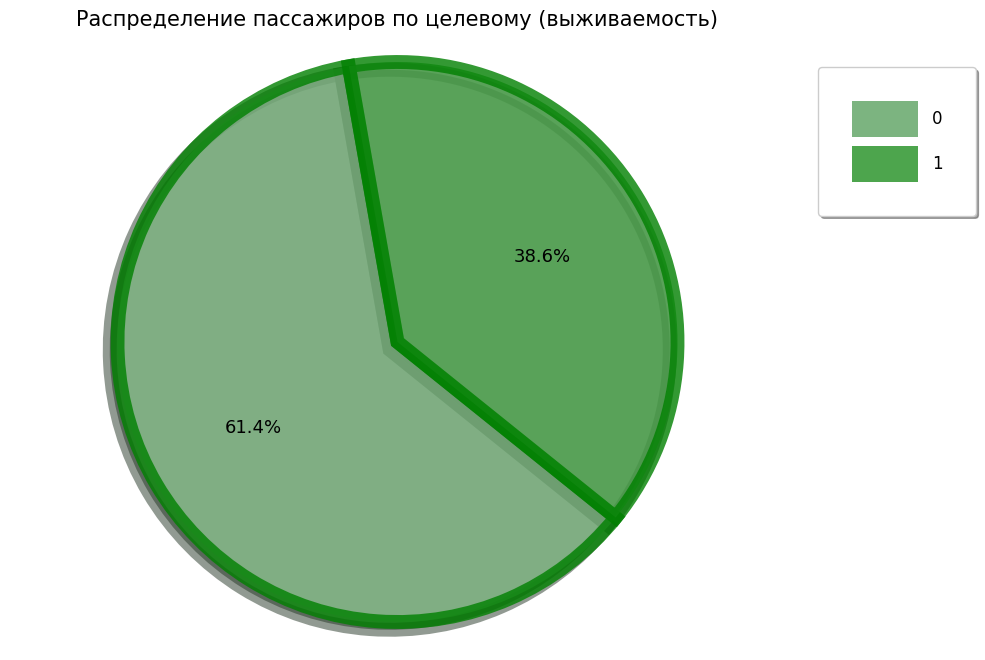

In [52]:
group_name = titanic['survived'].value_counts()

colors = ['#7cb480', '#4da54d']

custom_pie_chart(
    data=group_name,
    colors=colors,
    startangle=100,
    title='Распределение пассажиров по целевому (выживаемость)',
)


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Устранение аномалий</p></div>


<font color="green">**Вывод по гистограмме и "ящику с усами" 1 из раздела "Визуализация":**</font>


*Здесь и сейчас сложно проанализировать возможныеаномалии, потому что нужно смотреть параметр болеедетально. Перенесём в раздел EDA.*


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


## DF @titanic `embarked`.


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 121px;font-weight: 600;">Общий вывод</p></div>


---
**Аномалии:**
- Не обнаружены

---


<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 209px;font-weight: 600;">Визуализация данных</p></div>


**Круговая  диаграмма 1**


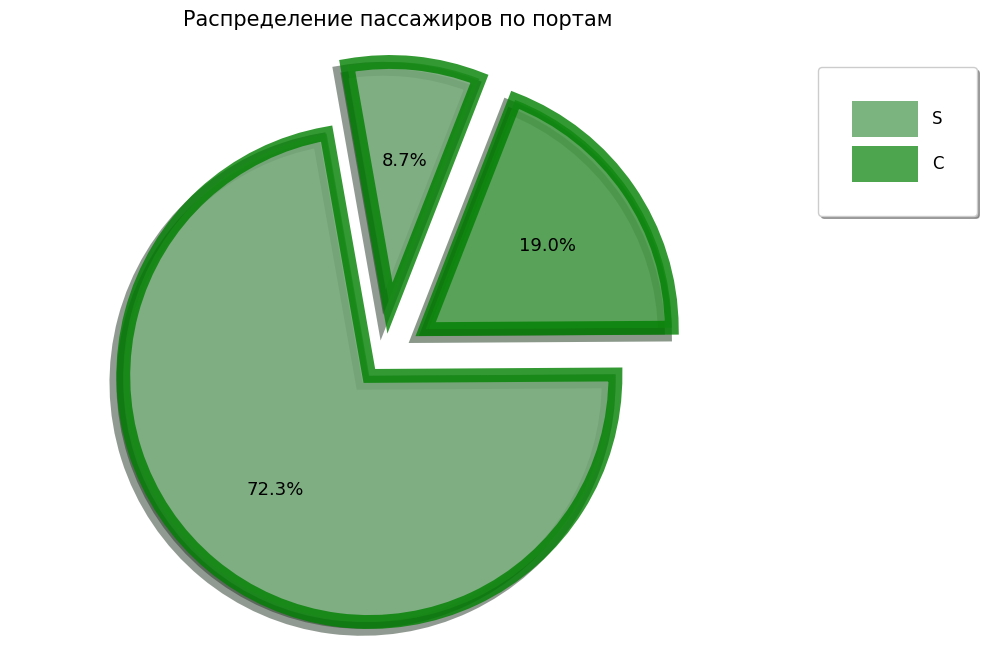

In [53]:
group_name = titanic['embarked'].value_counts()

custom_pie_chart(
    data=group_name,
    colors=colors,
    startangle=100,
    explode=[0.1, 0.2, 0.2],
    title='Распределение пассажиров по портам',
)

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 77px;font-weight: 600;">Метрики</p></div>


In [54]:
print(
    'Оценка сезонности:',
    (titanic['embarked'].value_counts())[:5],
    '',
    sep='\n'
)

Оценка сезонности:
embarked
S    640
C    168
Q     77
Name: count, dtype: int64



<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 220px;font-weight: 600;">Устранение пропусков</p></div>


In [55]:
titanic[titanic['embarked'].isna()]

,passenger_id,ticket_id,name,sex,age,same_importance_relatives,high_importance_relatives,category_significance,fare,cabin,survived,embarked
61,62,113572,"Icard, Miss. Amelie",female,38.0,0,0,1,80.0,B28,1,NaN
829,830,113572,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,1,80.0,B28,1,NaN


In [56]:
(
    titanic
    .dropna(subset=['embarked', 'cabin'])
    .groupby('embarked').agg({
        'cabin': lambda x: ' | '.join(x)
    })
)

,cabin
embarked,
C,C85 | B78 | D33 | B30 | A5 | D10 D12 | B58 B60...
Q,C78 | E101 | C78 | F38
S,C123 | E46 | G6 | C103 | D56 | A6 | C23 C25 C2...


**Вывод:**

*Какой-то закономерности я здесь не вижу, поэтому просто заполним пропуски модой.*

In [57]:
titanic = TitanicPreprocessor.fill_missing_embarked(titanic)

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <h3 class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 263px;font-weight: 600;">Оптимизация данных</h3></div>


In [58]:
titanic = TitanicPreprocessor.optimize_dtypes(titanic)

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


# Промежуточный вывод


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 300px;font-weight: 600;">Обобщение выводов предобработки</p></div>


<ul>
<li>

**@titanic `ticket_id`.**

Данные в этом признаке содержали аномалию, связанную с случайными символами "." и "/", но проведя исследование аномалии мы пришли к выводу, что проводить коррекцию данных не имеет смысла.

Некоторые люди с одной фамилией или иными признаками родства имели разные номера билетов, например билеты "2695", "2690".

Можно попробовать разделить признак ticket_id на id и строчную преписку из букв;
</li>

<li>

**@titanic `name`.**

Обозначение осознанности, которое несёт смысл вставлено в имя (Master, Mr, Miss, Mrs), когда лучше его вынести в отдельный признак на равне с признаком age. Создать признак age_level.

 поле name заложены имена и фамилии. Из-за имени дубликатов практически нет, что ломает нам всю картину для более глубокого анализа, следовательно нужно попробовать создать признак  family.
</li>

<li>

**@titanic `sex`.**

По какой-то причине на титанике было 577 человек мужского пола, в то время как женского пола всего 313.

Также пока не понятно что делать с пропусками. Нужно смотреть корреляции.

</li>

<li>

**@titanic `age`.**

Нужно создать новые признаки, объединив признак age с другими.

Подозрения на аномалии:
- Очень большое количество пропусков в признаке age связано с пассажирами 3ей категории;
- Большое количество детей меньше года;
- 77% пропущенных значений - люди из 3ей категории;
- 5 человек старше 70.
<br>

</li>

<li>

**@titanic `fare`.**

Люди, которые заплатили сверх цену платили за несколько кабин. Одна и та же цена  записывается каждому члену семьи.

Также было обнаружено, что есть определённые категории цен, но при этом сами по себе они сильно разнятся - нужно посмотреть под одну категорию попадают только члены одной семьи или в целом многие заплатили одинаково. Возможно сегментация может что-то прояснить в данных, чего мы не видели. (очень часто все дубликаты имеют одну категорию значимости, а при увеличении стоимости билета увеличиваются также и количества родственников, которых оформили на один билет)

Есть пассажиры, которые заплатили 0. Причина также не ясна.

Есть несколько закономерностей, которые связывают категорию людей не оплативших проезд:

1. Абсолютно все эти люди мужчины;
2. Каждый мужчина не оплативший проезд не имел никаких родственников;
3. Все сели в одном и тот же порту;
4. Все ехали либо по одиночке либо вместе с другими такими же
<br>
Мы могли бы счесть этих пассажиров важными, если бы в датасете не было ещё 500 человек абсолютно без родственников. То есть первые 3 признака буквально не говорят ни о чём, а 4ый как будто просто следствие из остальных.

В общем, в данных просто не хватает признаков, чтобы описать эту отдельную категорию людей, которые абсолютно не заплатили за проезд. Я склоняюсь к тому, чтобы заполнить эти нулевые значения. В любом случае их слишком мало, чтобы очень сильно углублятся в исследование - нужно иметь в виду.

</li>

<li>

**@titanic `cabin`.**

Удалить признак cabin, превратив его в набор признаков:
   - палуба;
   - признак неопределённости: 1 → конкретная каюта известна, 2+ -> пассажир связан с несколькими каютами;
   - каюта определенна однозначно;
   - члены семьи находятся далеко друг от друга на этаже;
   - один из членов семьи находится в конце корридора.
   - создать признак в одной кабине было больше одного человека (тут есть вероятность, что они повторяются даже без родства)
</li>
</ul>

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>


<div class="border" style="border: 2px solid black;width: 99%;height: auto;margin-top: 20px;border-bottom: none;"> <p class="legend" style="margin-top: -8px;margin-left: 10px;padding-left: 15px;background: white;width: 299px;font-weight: 600;">Неизученные признаки (уязвимости)</p></div>


* @titanic `sex`;
* @titanic `age`;
* @titanic `category_significance`;
* @titanic `fare`;
* @titanic `cabin`;
* @titanic `survived`;
* @titanic `embarked`.

<div class="border" style="border: 2px solid black;width: 99%;height: 10px;border-top: none;"></div>
